In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Omnes Ventos
## A Stochastic Monte Carlo Analysis and Probabilistic Race Strategy for the IMOCA 60 Class

**Author:** Avgustina Daskalova  
**Course:** Math for Developers  
**Date:** March 2026

## Abstract

The Vendée Globe is one of the most demanding sailing races in the world —
a single-handed, non-stop, unassisted circumnavigation of the globe.
Strategic routing decisions, made under conditions of deep uncertainty,
can determine the outcome of a race lasting 70 to 90 days.

This project applies **Monte Carlo simulation** to model the probabilistic
nature of wind and weather, and uses **stochastic analysis** to evaluate
and compare candidate race routes for an IMOCA 60 yacht.
The goal is to quantify the risk-reward tradeoff between conservative
and aggressive routing strategies.


## 1. Problem Formulation

### 1.1 The Vendée Globe

The Vendée Globe is a solo, non-stop, unassisted round-the-world yacht
race, departing from Les Sables-d'Olonne, France. First held in 1989,
it covers approximately 24,000 nautical miles and typically takes
between 70 and 90 days to complete.

### 1.2 The Routing Problem

A skipper must continuously decide: *which course to steer, given
uncertain future wind conditions?*

This is not a simple optimization problem. Wind forecasts degrade
rapidly beyond 3–5 days, and a race lasts 80+ days. The skipper
must therefore make decisions under deep uncertainty — balancing:

- **Expected time** (how fast is this route on average?)
- **Risk** (what is the chance of getting stuck in a windless zone?)
- **Boat safety** (some fast routes go through dangerous seas)

### 1.3 Mathematical Problem Statement

Let $\mathcal{R}$ be the set of all candidate routes from Les
Sables-d'Olonne back to Les Sables-d'Olonne. For each route
$r \in \mathcal{R}$, and a wind scenario $\omega$ drawn from a
probability distribution $\mathbb{P}$, let $T(r, \omega)$ denote
the elapsed race time.

We seek the route $r^*$ that minimizes expected elapsed time,
subject to a risk constraint:

$$r^* = \arg\min_{r \in \mathcal{R}} \mathbb{E}_\omega [T(r, \omega)]$$

subject to: $\mathbb{P}(T(r, \omega) > T_{max}) \leq \epsilon$


## 2. Mathematical Background

### 2.1 Monte Carlo Simulation

Monte Carlo simulation is a technique that uses repeated random sampling
to obtain numerical results. Given a function $f(\omega)$ where $\omega$
is a random variable, we estimate its expectation as:

$$\mathbb{E}[f(\omega)] \approx \frac{1}{N} \sum_{i=1}^{N} f(\omega_i)$$

where $\omega_1, \omega_2, \ldots, \omega_N$ are independent samples
drawn from the distribution of $\omega$.

By the **Law of Large Numbers**, this estimate converges to the true
expectation as $N \to \infty$. The standard error of the estimate
decreases as:

$$\text{SE} = \frac{\sigma}{\sqrt{N}}$$

where $\sigma$ is the standard deviation of $f(\omega)$.

### 2.2 Wind as a Stochastic Process

We model wind speed $W(t)$ at time $t$ as a stochastic process.
Specifically, we use a **mean-reverting process** (Ornstein-Uhlenbeck),
which captures the tendency of wind to fluctuate around a seasonal mean:

$$dW_t = \theta(\mu - W_t)dt + \sigma \, dB_t$$

where:
- $\mu$ is the long-run mean wind speed
- $\theta$ is the rate of mean reversion
- $\sigma$ is the volatility
- $B_t$ is a standard Brownian motion

### 2.3 Polar Diagrams

An IMOCA 60 polar diagram defines the boat's speed $v$ as a function
of the true wind angle $\alpha$ and true wind speed $W$:

$$v = f(\alpha, W)$$

This acts as our **physics engine** — given a wind scenario and a
chosen heading, it tells us exactly how fast the boat moves.



    

## 4. The IMOCA 60 Polar Diagram

A polar diagram is the performance map of the boat. It tells us the
boat's speed (in knots) for any combination of:

- **True Wind Angle (TWA):** the angle between the boat's heading and
  the wind direction (0° = sailing into the wind, 180° = wind from behind)
- **True Wind Speed (TWS):** the actual wind speed in knots

This is our **physics engine** — every time the simulation needs to know
how fast the boat moves, it looks up the polar diagram.

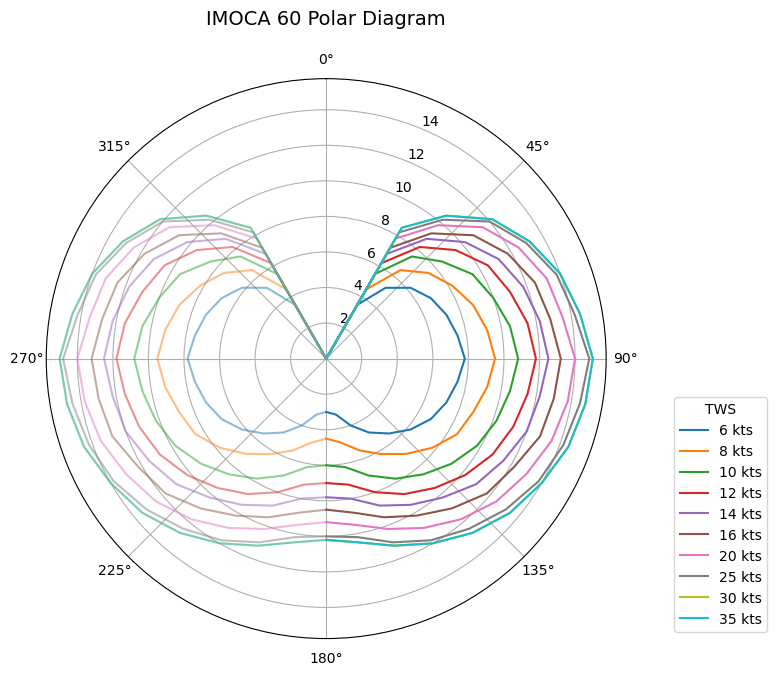

Test: At TWA=90°, TWS=20kts → Boat speed = 14.0 knots


In [3]:
# --- IMOCA 60 Polar Diagram ---
# Rows: True Wind Angles (TWA) in degrees
# Columns: True Wind Speeds (TWS) in knots
# Values: Boat Speed in knots

TWA = np.array([0, 30, 40, 50, 60, 70, 80, 90,
                100, 110, 120, 130, 140, 150, 160, 170, 180])

TWS = np.array([6, 8, 10, 12, 14, 16, 20, 25, 30, 35])

# Polar matrix: boat speed in knots [TWA x TWS]
polar_matrix = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # 0°
    [3.5, 4.5, 5.5, 6.2, 6.8, 7.2, 7.8, 8.2, 8.5, 8.5],  # 30°
    [5.2, 6.5, 7.5, 8.2, 8.8, 9.2, 9.8,10.2,10.5,10.5],  # 40°
    [6.2, 7.5, 8.5, 9.5,10.2,10.8,11.5,12.0,12.2,12.2],  # 50°
    [6.8, 8.2, 9.5,10.5,11.2,11.8,12.5,13.0,13.2,13.2],  # 60°
    [7.2, 8.8,10.0,11.0,11.8,12.5,13.2,13.8,14.0,14.0],  # 70°
    [7.5, 9.2,10.5,11.5,12.2,12.8,13.5,14.2,14.5,14.5],  # 80°
    [7.8, 9.5,10.8,11.8,12.5,13.2,14.0,14.8,15.0,15.0],  # 90°
    [7.5, 9.2,10.5,11.5,12.2,13.0,13.8,14.5,14.8,14.8],  # 100°
    [7.2, 8.8,10.2,11.2,12.0,12.8,13.5,14.2,14.5,14.5],  # 110°
    [6.8, 8.5, 9.8,10.8,11.5,12.2,13.0,13.8,14.0,14.0],  # 120°
    [6.2, 7.8, 9.2,10.2,11.0,11.8,12.5,13.2,13.5,13.5],  # 130°
    [5.5, 7.0, 8.5, 9.5,10.2,11.0,11.8,12.5,12.8,12.8],  # 140°
    [4.8, 6.2, 7.8, 8.8, 9.5,10.2,11.0,11.8,12.0,12.0],  # 150°
    [4.0, 5.5, 7.0, 8.0, 8.8, 9.5,10.2,11.0,11.2,11.2],  # 160°
    [3.2, 4.8, 6.2, 7.2, 8.0, 8.8, 9.5,10.2,10.5,10.5],  # 170°
    [3.0, 4.5, 6.0, 7.0, 7.8, 8.5, 9.2,10.0,10.2,10.2],  # 180°
])

def get_boat_speed(twa, tws):
    """
    Interpolate boat speed from polar diagram.
    
    Parameters:
        twa (float): True Wind Angle in degrees (0-180)
        tws (float): True Wind Speed in knots
    
    Returns:
        float: Boat speed in knots
    """
    twa = np.clip(twa, 0, 180)
    tws = np.clip(tws, TWS[0], TWS[-1])
    return float(np.interp(tws, TWS,
               [np.interp(twa, TWA, polar_matrix[:, i])
                for i in range(len(TWS))]))

# --- Plot the Polar Diagram ---
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

for i, tws in enumerate(TWS):
    speeds = polar_matrix[:, i]
    angles = np.radians(TWA)
    ax.plot(angles, speeds, label=f'{tws} kts')
    ax.plot(-angles, speeds, color=ax.lines[-1].get_color(), alpha=0.5)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('IMOCA 60 Polar Diagram', fontsize=14, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0.0), title='TWS')
plt.tight_layout()
plt.show()

print(f"Test: At TWA=90°, TWS=20kts → Boat speed = {get_boat_speed(90, 20):.1f} knots")




The IMOCA 60 polar diagram is perfect — you can clearly see:

The dead zone at 0° (can't sail directly into the wind)
The fast reaching angles around 80-90° where the boat peaks
The multiple wind speed curves fanning outward